# 第四讲：AHP、熵权法与 TOPSIS 综合评价模型

本 Notebook 使用一个“城市宜居水平综合评价”案例，完整演示：

1. 如何构建综合评价问题的数据矩阵；
2. 如何进行指标正向化与标准化；
3. 如何用 AHP 计算主观权重，并进行一致性检验；
4. 如何用熵权法计算客观权重；
5. 如何组合权重，并用 TOPSIS 得到综合排名；
6. 如何输出结果表格、图像和论文可用结论。

综合评价问题的核心不是“把多个指标加起来”，而是要解决三个问题：

- **指标方向不同**：有些指标越大越好，有些指标越小越好；
- **指标量纲不同**：万元、百分比、分钟、指数不能直接相加；
- **指标重要性不同**：不同指标对评价结果的影响程度通常不同。

## 1. 导入库与读取数据

假设有 $m$ 个评价对象，$n$ 个评价指标，可以把原始数据写成指标矩阵：

$$
X = (x_{ij})_{m \times n}
$$

其中：

- $i=1,2,\dots,m$ 表示第 $i$ 个评价对象；
- $j=1,2,\dots,n$ 表示第 $j$ 个评价指标；
- $x_{ij}$ 表示第 $i$ 个对象在第 $j$ 个指标上的原始取值。

在本案例中，评价对象是城市，评价指标包括经济、公共服务、生态环境、交通、污染和住房压力等因素。

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文显示设置：如果本地环境字体不同，可以将字体名改为本机可用中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '第四讲示例数据.csv'
OUTPUT_DIR = '第四讲_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df

,城市,人均GDP_万元,公共服务评分,绿化覆盖率_%,平均通勤时间_min,污染指数,住房压力指数
0,城市C,9.95,69.6,37.7,45.8,68.8,60.0
1,城市J,14.49,89.6,56.7,27.9,51.3,46.5
2,城市G,12.99,80.8,50.9,35.9,50.4,53.6
3,城市E,9.82,72.0,43.5,39.2,72.5,64.8
4,城市A,7.83,66.6,30.4,52.3,81.8,67.2
5,城市D,10.01,70.9,39.2,42.1,69.0,55.9
6,城市B,8.23,63.9,38.6,49.7,76.3,67.3
7,城市H,14.07,85.7,45.8,39.8,51.7,57.1
8,城市I,13.36,83.4,47.6,37.6,54.8,54.5
9,城市F,11.32,76.6,40.4,39.7,68.3,64.7


## 2. 明确指标方向

综合评价中常见三类指标：

1. **正向指标**：数值越大越好，例如人均 GDP、公共服务评分、绿化覆盖率；
2. **负向指标**：数值越小越好，例如平均通勤时间、污染指数、住房压力指数；
3. **中间型或区间型指标**：越接近某个目标值或区间越好，例如 pH 值、温度、负荷率等。

本讲主要处理正向指标和负向指标。为了后续计算，所有指标都需要统一成“越大越好”。

In [2]:
indicators = ['人均GDP_万元', '公共服务评分', '绿化覆盖率_%', '平均通勤时间_min', '污染指数', '住房压力指数']
indicator_types = {
    '人均GDP_万元': '正向',
    '公共服务评分': '正向',
    '绿化覆盖率_%': '正向',
    '平均通勤时间_min': '负向',
    '污染指数': '负向',
    '住房压力指数': '负向'
}

pd.DataFrame({
    '指标': indicators,
    '指标方向': [indicator_types[col] for col in indicators]
})

,指标,指标方向
0,人均GDP_万元,正向
1,公共服务评分,正向
2,绿化覆盖率_%,正向
3,平均通勤时间_min,负向
4,污染指数,负向
5,住房压力指数,负向


## 3. 指标正向化与极差标准化

不同指标的量纲和方向不同，不能直接相加。常见处理方式是先进行正向化，再进行标准化。

### 3.1 正向指标

若指标越大越好，可以用：

$$
z_{ij}=\frac{x_{ij}-\min_i x_{ij}}{\max_i x_{ij}-\min_i x_{ij}}
$$

### 3.2 负向指标

若指标越小越好，可以用：

$$
z_{ij}=\frac{\max_i x_{ij}-x_{ij}}{\max_i x_{ij}-\min_i x_{ij}}
$$

处理后，所有 $z_{ij}$ 都落在 $[0,1]$ 附近，并且数值越大表示表现越好。

In [3]:
def minmax_positive(series):
    """正向指标极差标准化：越大越好。"""
    return (series - series.min()) / (series.max() - series.min())

def minmax_negative(series):
    """负向指标极差标准化：越小越好，先反向再标准化。"""
    return (series.max() - series) / (series.max() - series.min())

def orient_and_standardize(data, indicators, indicator_types):
    Z = pd.DataFrame(index=data.index)
    for col in indicators:
        if indicator_types[col] == '正向':
            Z[col] = minmax_positive(data[col])
        elif indicator_types[col] == '负向':
            Z[col] = minmax_negative(data[col])
        else:
            raise ValueError(f'{col} 的指标方向暂未处理')
    return Z

Z = orient_and_standardize(df, indicators, indicator_types)
Z.insert(0, '城市', df['城市'])
Z

,城市,人均GDP_万元,公共服务评分,绿化覆盖率_%,平均通勤时间_min,污染指数,住房压力指数
0,城市C,0.318318,0.221790,0.277567,0.266393,0.414013,0.350962
1,城市J,1.000000,1.000000,1.000000,1.000000,0.971338,1.000000
2,城市G,0.774775,0.657588,0.779468,0.672131,1.000000,0.658654
3,城市E,0.298799,0.315175,0.498099,0.536885,0.296178,0.120192
4,城市A,0.000000,0.105058,0.000000,0.000000,0.000000,0.004808
5,城市D,0.327327,0.272374,0.334601,0.418033,0.407643,0.548077
6,城市B,0.060060,0.000000,0.311787,0.106557,0.175159,0.000000
7,城市H,0.936937,0.848249,0.585551,0.512295,0.958599,0.490385
8,城市I,0.830330,0.758755,0.653992,0.602459,0.859873,0.615385
9,城市F,0.524024,0.494163,0.380228,0.516393,0.429936,0.125000


标准化后的数据可以作为 AHP、熵权法和 TOPSIS 的共同输入。注意：标准化后的数值不是原始单位，而是相对表现分值。

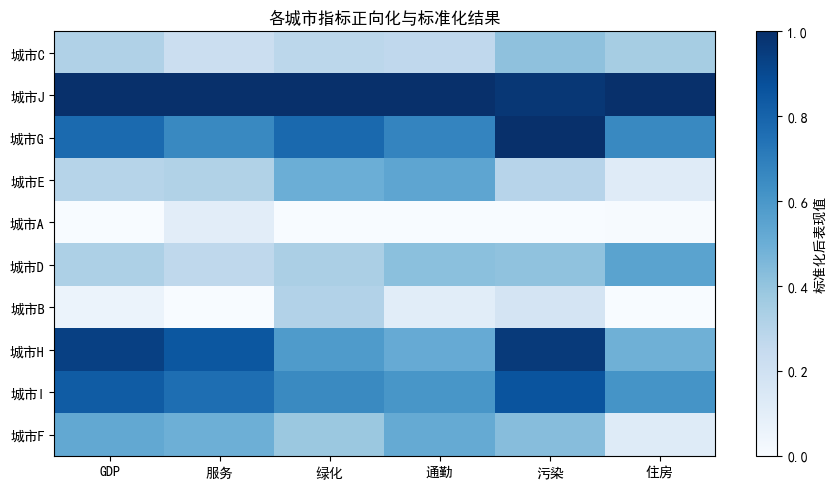

In [ ]:
Z_numeric = Z[indicators]
plt.figure(figsize=(9, 5))
plt.imshow(Z_numeric.values, aspect='auto', cmap='Blues')
plt.colorbar(label='标准化后表现值')
plt.xticks(range(len(indicators)), ['GDP', '服务', '绿化', '通勤', '污染', '住房'], rotation=0)
plt.yticks(range(len(df)), df['城市'])
plt.title('各城市指标正向化与标准化结果')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '标准化指标热力图.png'), dpi=180)
plt.show()

## 4. AHP 层次分析法

AHP 主要用于计算**主观权重**。它不是直接给出权重，而是让我们对指标进行两两比较，形成判断矩阵。

假设有 $n$ 个指标，判断矩阵记为：

$$
A=(a_{ij})_{n\times n}
$$

其中：

- $a_{ij}$ 表示指标 $i$ 相对于指标 $j$ 的重要程度；
- $a_{ij}>0$；
- $a_{ij}=1/a_{ji}$；
- $a_{ii}=1$。

判断矩阵通常使用 1—9 标度法。比如 $a_{ij}=3$ 表示指标 $i$ 比指标 $j$ 稍重要；$a_{ij}=1/3$ 表示指标 $j$ 比指标 $i$ 稍重要。

In [5]:
criteria = ['经济水平', '公共服务', '生态环境', '通勤效率', '污染控制', '住房压力']

# AHP 判断矩阵示例：行指标相对于列指标的重要程度
A = np.array([
    [1,   2,   2,   3,   3,   4],
    [1/2, 1,   1,   2,   2,   3],
    [1/2, 1,   1,   2,   3,   3],
    [1/3, 1/2, 1/2, 1,   2,   2],
    [1/3, 1/2, 1/3, 1/2, 1,   2],
    [1/4, 1/3, 1/3, 1/2, 1/2, 1]
], dtype=float)

A_df = pd.DataFrame(A, index=criteria, columns=criteria)
A_df

,经济水平,公共服务,生态环境,通勤效率,污染控制,住房压力
经济水平,1.000000,2.000000,2.000000,3.0,3.0,4.0
公共服务,0.500000,1.000000,1.000000,2.0,2.0,3.0
生态环境,0.500000,1.000000,1.000000,2.0,3.0,3.0
通勤效率,0.333333,0.500000,0.500000,1.0,2.0,2.0
污染控制,0.333333,0.500000,0.333333,0.5,1.0,2.0
住房压力,0.250000,0.333333,0.333333,0.5,0.5,1.0


### 4.1 AHP 权重计算

常见做法是特征值法。若 $A$ 为判断矩阵，则计算：

$$
Aw=\lambda_{\max}w
$$

其中：

- $\lambda_{\max}$ 是判断矩阵的最大特征值；
- $w$ 是对应的特征向量；
- 对 $w$ 进行归一化后得到指标权重。

归一化要求：

$$
\sum_{j=1}^{n}w_j=1
$$

In [ ]:
def ahp_weight(matrix):
    """使用特征值法计算 AHP 权重，并返回一致性检验结果。"""
    matrix = np.array(matrix, dtype=float)
    n = matrix.shape[0]  # 指标数目
    eig_values, eig_vectors = np.linalg.eig(matrix)  # eig_vectors 是列向量
    max_index = np.argmax(eig_values.real)  # 找到最大特征值对应的索引
    lambda_max = eig_values[max_index].real  # 找到最大特征值的实部  # CI = (lambda_max - n) / (n - 1)
    weight_vector = eig_vectors[:, max_index].real  # 取的是第max_index列的特征向量
    weight_vector = np.abs(weight_vector)  # 取绝对值，避免负权重
    weight_vector = weight_vector / weight_vector.sum()  # 归一化，保证权重和为1

    RI_dict = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
    CI = (lambda_max - n) / (n - 1)
    RI = RI_dict[n]
    CR = CI / RI if RI != 0 else 0  # 做保护机制
    return weight_vector, lambda_max, CI, CR

ahp_w, lambda_max, CI, CR = ahp_weight(A)
ahp_result = pd.DataFrame({
    '指标': criteria,
    'AHP权重': ahp_w
})
ahp_result

,指标,AHP权重
0,经济水平,0.328653
1,公共服务,0.191809
2,生态环境,0.206553
3,通勤效率,0.120265
4,污染控制,0.090038
5,住房压力,0.062682


### 4.2 一致性检验

AHP 需要检查判断矩阵是否前后矛盾。一致性指标为：

$$
CI=\frac{\lambda_{\max}-n}{n-1}
$$

一致性比例为：

$$
CR=\frac{CI}{RI}
$$

通常认为：

$$
CR<0.10
$$

时，判断矩阵的一致性可以接受。若 $CR$ 太大，说明判断矩阵存在较明显矛盾，需要重新调整两两比较关系。

In [7]:
print(f'最大特征值 lambda_max = {lambda_max:.4f}')
print(f'CI = {CI:.4f}')
print(f'CR = {CR:.4f}')
print('一致性是否通过：', '通过' if CR < 0.10 else '不通过，需要调整判断矩阵')

最大特征值 lambda_max = 6.1068
CI = 0.0214
CR = 0.0172
一致性是否通过： 通过


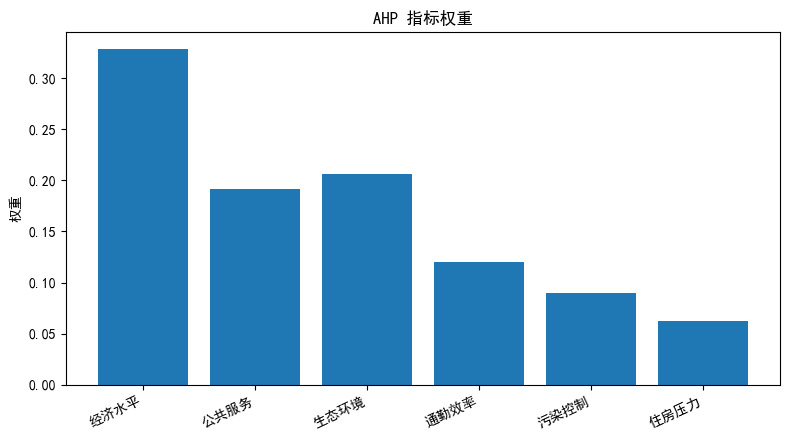

In [8]:
plt.figure(figsize=(8, 4.5))
plt.bar(criteria, ahp_w)
plt.title('AHP 指标权重')
plt.ylabel('权重')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'AHP权重.png'), dpi=180)
plt.show()

## 5. 熵权法

熵权法用于计算**客观权重**。它的基本思想是：

> 一个指标在不同对象之间差异越大，越能区分对象，提供的信息越多，因此权重可以更高。

设标准化后的数据为 $z_{ij}$。首先计算第 $j$ 个指标下第 $i$ 个对象所占比例：

$$
p_{ij}=\frac{z_{ij}}{\sum_{i=1}^{m}z_{ij}}
$$

再计算第 $j$ 个指标的信息熵：

$$
e_j=-k\sum_{i=1}^{m}p_{ij}\ln p_{ij}, \quad k=\frac{1}{\ln m}
$$

差异系数：

$$
d_j=1-e_j
$$

最后得到熵权：

$$
w_j=\frac{d_j}{\sum_{j=1}^{n}d_j}
$$

In [9]:
def entropy_weight(Z_numeric):
    """根据正向化、标准化后的矩阵计算熵权法权重。"""
    Z_arr = np.array(Z_numeric, dtype=float)
    m, n = Z_arr.shape
    eps = 1e-12
    P = Z_arr / (Z_arr.sum(axis=0) + eps)
    k = 1 / np.log(m)
    E = -k * np.sum(P * np.log(P + eps), axis=0)
    D = 1 - E
    W = D / D.sum()
    return W, E, D

entropy_w, entropy_E, entropy_D = entropy_weight(Z_numeric)
entropy_result = pd.DataFrame({
    '指标': criteria,
    '熵值E': entropy_E,
    '差异系数D': entropy_D,
    '熵权法权重': entropy_w
})
entropy_result

,指标,熵值E,差异系数D,熵权法权重
0,经济水平,0.877347,0.122653,0.176632
1,公共服务,0.879822,0.120178,0.173067
2,生态环境,0.916069,0.083931,0.120868
3,通勤效率,0.904422,0.095578,0.137641
4,污染控制,0.895615,0.104385,0.150325
5,住房压力,0.832325,0.167675,0.241467


熵权法结果的解释要注意：

- 熵权高，说明该指标在样本中差异较大，区分度较强；
- 熵权低，说明该指标在样本中差异较小，区分度较弱；
- 熵权不是“现实重要性”的绝对判断，而是由数据差异得到的客观权重。

In [10]:
weight_compare = pd.DataFrame({
    '指标': criteria,
    'AHP权重': ahp_w,
    '熵权法权重': entropy_w
})
weight_compare

,指标,AHP权重,熵权法权重
0,经济水平,0.328653,0.176632
1,公共服务,0.191809,0.173067
2,生态环境,0.206553,0.120868
3,通勤效率,0.120265,0.137641
4,污染控制,0.090038,0.150325
5,住房压力,0.062682,0.241467


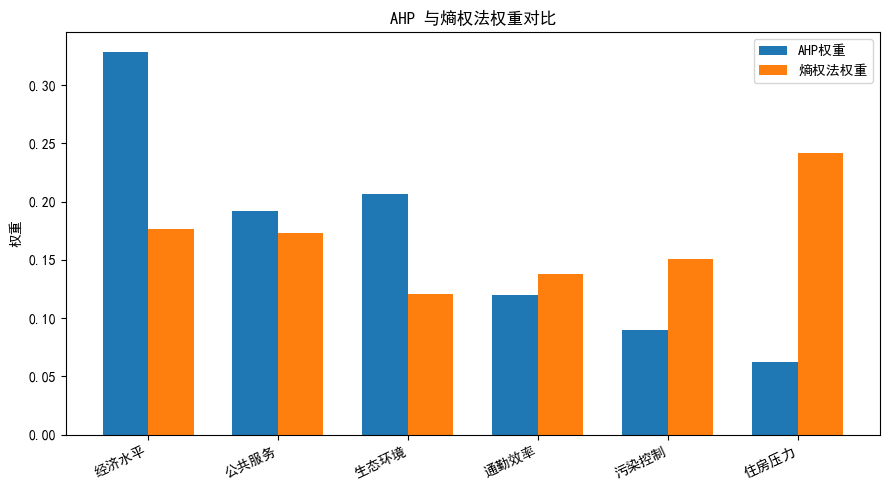

In [11]:
x = np.arange(len(criteria))
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, ahp_w, width, label='AHP权重')
plt.bar(x + width/2, entropy_w, width, label='熵权法权重')
plt.xticks(x, criteria, rotation=25, ha='right')
plt.ylabel('权重')
plt.title('AHP 与熵权法权重对比')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'AHP与熵权法权重对比.png'), dpi=180)
plt.show()

## 6. 组合权重

AHP 体现主观判断，熵权法体现客观数据差异。在竞赛论文中，常见做法是构造组合权重：

$$
w_j = \alpha w_j^{AHP} + (1-\alpha)w_j^{Entropy}
$$

其中 $\alpha\in[0,1]$。

若没有额外理由，可以取 $\alpha=0.5$，表示主观权重与客观权重各占一半。也可以根据题目背景调整 $\alpha$。

In [12]:
alpha = 0.5
combined_w = alpha * ahp_w + (1 - alpha) * entropy_w
combined_w = combined_w / combined_w.sum()

combined_result = pd.DataFrame({
    '指标': criteria,
    'AHP权重': ahp_w,
    '熵权法权重': entropy_w,
    '组合权重': combined_w
})
combined_result

,指标,AHP权重,熵权法权重,组合权重
0,经济水平,0.328653,0.176632,0.252642
1,公共服务,0.191809,0.173067,0.182438
2,生态环境,0.206553,0.120868,0.163711
3,通勤效率,0.120265,0.137641,0.128953
4,污染控制,0.090038,0.150325,0.120181
5,住房压力,0.062682,0.241467,0.152074


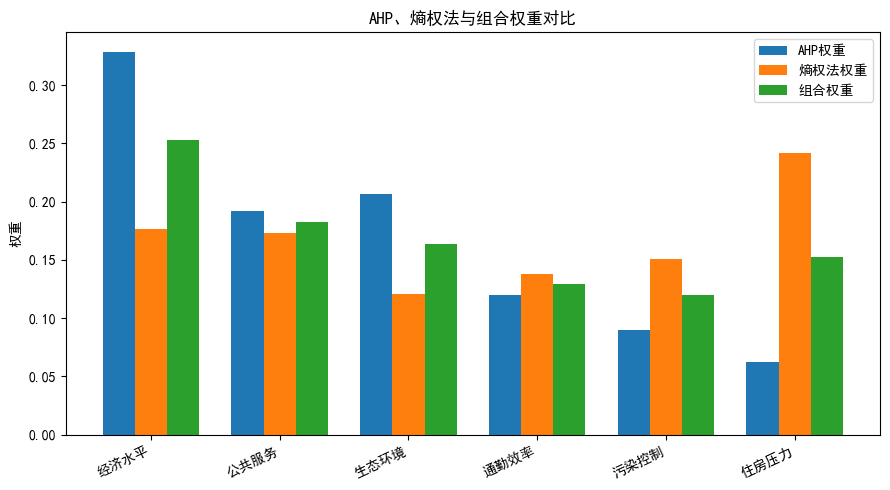

In [13]:
x = np.arange(len(criteria))
width = 0.25
plt.figure(figsize=(9, 5))
plt.bar(x - width, ahp_w, width, label='AHP权重')
plt.bar(x, entropy_w, width, label='熵权法权重')
plt.bar(x + width, combined_w, width, label='组合权重')
plt.xticks(x, criteria, rotation=25, ha='right')
plt.ylabel('权重')
plt.title('AHP、熵权法与组合权重对比')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '组合权重对比.png'), dpi=180)
plt.show()

## 7. TOPSIS 综合评价

TOPSIS 的思想是：

> 一个好的评价对象，应该距离“正理想解”越近，距离“负理想解”越远。

首先对标准化矩阵进行向量归一化：

$$
r_{ij}=\frac{z_{ij}}{\sqrt{\sum_{i=1}^{m}z_{ij}^{2}}}
$$

再乘以权重，得到加权矩阵：

$$
v_{ij}=w_j r_{ij}
$$

正理想解：

$$
A^+=\{\max_i v_{ij}\}
$$

负理想解：

$$
A^-=\{\min_i v_{ij}\}
$$

到正理想解和负理想解的距离为：

$$
D_i^+=\sqrt{\sum_{j=1}^{n}(v_{ij}-A_j^+)^2}
$$

$$
D_i^-=\sqrt{\sum_{j=1}^{n}(v_{ij}-A_j^-)^2}
$$

综合接近度为：

$$
C_i=\frac{D_i^-}{D_i^+ + D_i^-}
$$

$C_i$ 越大，表示对象越接近正理想解，综合评价排名越靠前。

In [ ]:
def topsis_score(Z_numeric, weights):
    """根据标准化矩阵和权重计算 TOPSIS 综合得分。"""
    Z_arr = np.array(Z_numeric, dtype=float)
    weights = np.array(weights, dtype=float)

    R = Z_arr / np.sqrt((Z_arr ** 2).sum(axis=0))   # 列归一化，L2范数为1 
    V = R * weights  # 矩阵对应元素的乘法  A @ B 线性代数中的矩阵乘法
    ideal_positive = V.max(axis=0)
    ideal_negative = V.min(axis=0)
    D_positive = np.sqrt(((V - ideal_positive) ** 2).sum(axis=1))
    D_negative = np.sqrt(((V - ideal_negative) ** 2).sum(axis=1))
    C = D_negative / (D_positive + D_negative)
    return C, D_positive, D_negative, V

score, D_pos, D_neg, V = topsis_score(Z_numeric, combined_w)

topsis_result = pd.DataFrame({
    '城市': df['城市'],
    'D正_距正理想解': D_pos,
    'D负_距负理想解': D_neg,
    'TOPSIS得分': score
})
topsis_result['排名'] = topsis_result['TOPSIS得分'].rank(ascending=False, method='min').astype(int)
topsis_result = topsis_result.sort_values('排名')
topsis_result

,城市,D正_距正理想解,D负_距负理想解,TOPSIS得分,排名
1,城市J,0.001672,0.233225,0.992880,1
2,城市G,0.064826,0.173373,0.727851,2
8,城市I,0.066978,0.171996,0.719728,3
7,城市H,0.074724,0.179727,0.706332,4
9,城市F,0.139295,0.103891,0.427206,5
5,城市D,0.148735,0.089003,0.374375,6
3,城市E,0.159761,0.082582,0.340764,7
0,城市C,0.164134,0.071009,0.301982,8
6,城市B,0.213859,0.032917,0.133390,9
4,城市A,0.228978,0.010715,0.044703,10


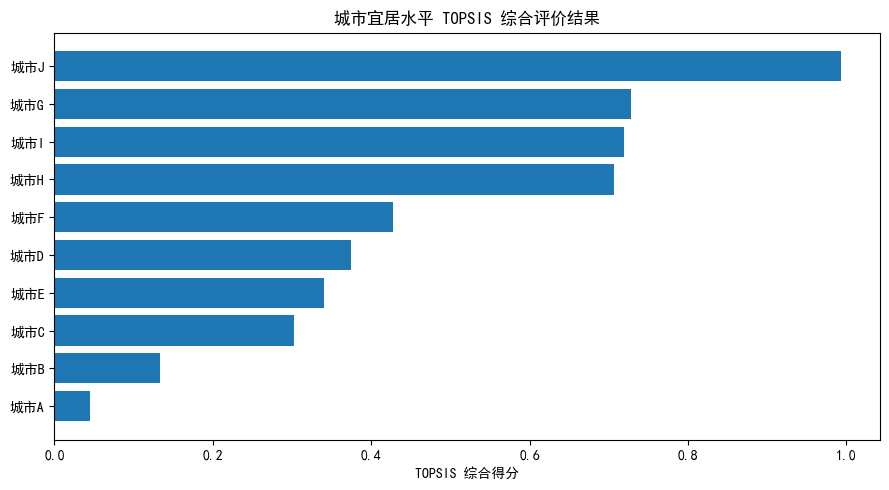

In [ ]:
plt.figure(figsize=(9, 5))
plot_df = topsis_result.sort_values('TOPSIS得分', ascending=True)
plt.barh(plot_df['城市'], plot_df['TOPSIS得分']) #横着画条形统计图
plt.xlabel('TOPSIS 综合得分')
plt.title('城市宜居水平 TOPSIS 综合评价结果')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'TOPSIS综合评价排名.png'), dpi=180)
plt.show()

## 8. 结果解释

综合评价结果不能只给排名，还需要说明排名背后的原因。一般可以从三个角度解释：

1. **综合得分**：哪个对象得分最高，哪个对象得分最低；
2. **指标权重**：哪些指标在评价中影响较大；
3. **单项表现**：排名靠前对象在哪些指标上有优势，排名靠后对象在哪些指标上存在短板。

In [16]:
# 找出排名最高和最低的城市，并对比其标准化指标表现
best_city = topsis_result.iloc[0]['城市']
worst_city = topsis_result.iloc[-1]['城市']

compare_df = Z[Z['城市'].isin([best_city, worst_city])].set_index('城市')[indicators]
compare_df

,人均GDP_万元,公共服务评分,绿化覆盖率_%,平均通勤时间_min,污染指数,住房压力指数
城市,,,,,,
城市J,1.0,1.000000,1.0,1.0,0.971338,1.000000
城市A,0.0,0.105058,0.0,0.0,0.000000,0.004808


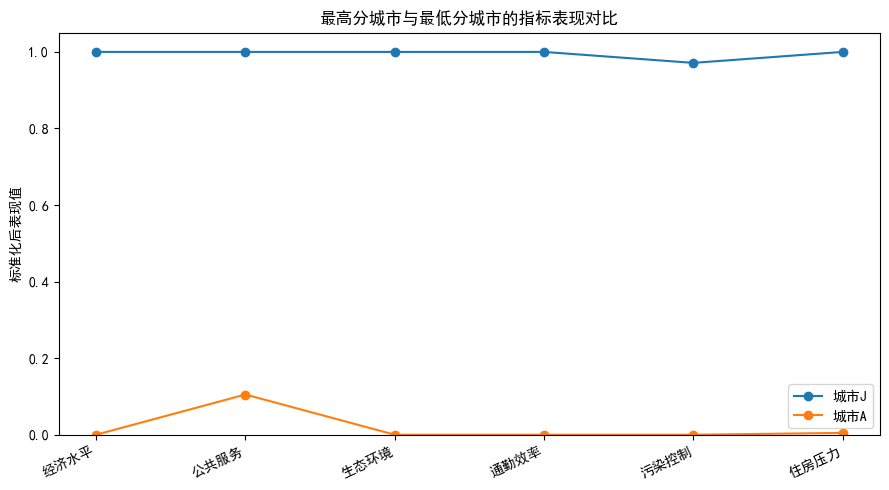

In [17]:
compare_plot = compare_df.T
plt.figure(figsize=(9, 5))
for city in compare_plot.columns:
    plt.plot(criteria, compare_plot[city], marker='o', label=city)
plt.ylim(0, 1.05)
plt.ylabel('标准化后表现值')
plt.title(f'最高分城市与最低分城市的指标表现对比')
plt.xticks(rotation=25, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '最高分与最低分城市指标对比.png'), dpi=180)
plt.show()

## 9. 权重敏感性分析

综合评价结果可能受权重影响。为了说明模型结果是否稳定，可以改变组合权重中的 $\alpha$，观察排名是否发生明显变化。

组合权重为：

$$
w_j(\alpha)=\alpha w_j^{AHP}+(1-\alpha)w_j^{Entropy}
$$

当 $\alpha$ 从 0 变化到 1 时：

- $\alpha=0$ 表示完全使用熵权法；
- $\alpha=1$ 表示完全使用 AHP；
- 若主要排名变化不大，说明模型结果较稳定；
- 若排名变化很大，说明结果对权重较敏感，需要谨慎解释。

In [ ]:
alphas = np.linspace(0, 1, 11)  # 生成 0 到 1 的 11 个 alpha 值
sensitivity_records = []

for a in alphas:
    w_alpha = a * ahp_w + (1 - a) * entropy_w
    w_alpha = w_alpha / w_alpha.sum()
    score_alpha, _, _, _ = topsis_score(Z_numeric, w_alpha)
    temp = pd.DataFrame({'城市': df['城市'], 'alpha': a, 'TOPSIS得分': score_alpha})
    temp['排名'] = temp['TOPSIS得分'].rank(ascending=False, method='min').astype(int)
    sensitivity_records.append(temp)

sensitivity_df = pd.concat(sensitivity_records, ignore_index=True)
sensitivity_pivot = sensitivity_df.pivot(index='alpha', columns='城市', values='排名')
sensitivity_pivot

城市,城市A,城市B,城市C,城市D,城市E,城市F,城市G,城市H,城市I,城市J
alpha,,,,,,,,,,
0.0,10,9,7,5,8,6,2,4,3,1
0.1,10,9,7,5,8,6,2,4,3,1
0.2,10,9,8,5,7,6,2,4,3,1
0.3,10,9,8,6,7,5,2,4,3,1
0.4,10,9,8,6,7,5,2,4,3,1
0.5,10,9,8,6,7,5,2,4,3,1
0.6,10,9,8,6,7,5,2,4,3,1
0.7,10,9,8,6,7,5,2,4,3,1
0.8,10,9,8,7,6,5,3,2,4,1


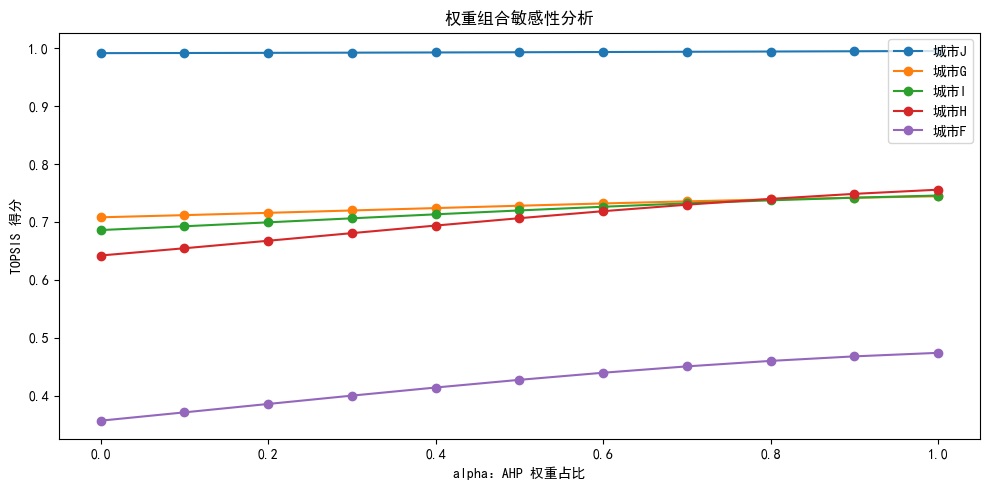

In [19]:
plt.figure(figsize=(10, 5))
# 只展示排名前几名城市的变化，避免图太拥挤
selected_cities = topsis_result.head(5)['城市'].tolist()
for city in selected_cities:
    city_scores = sensitivity_df[sensitivity_df['城市'] == city]
    plt.plot(city_scores['alpha'], city_scores['TOPSIS得分'], marker='o', label=city)
plt.xlabel('alpha：AHP 权重占比')
plt.ylabel('TOPSIS 得分')
plt.title('权重组合敏感性分析')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '权重敏感性分析.png'), dpi=180)
plt.show()

## 10. 保存结果

建模竞赛中，建议把关键结果保存为表格和图片，方便插入论文。常见保存内容包括：

- 原始数据；
- 标准化数据；
- AHP 权重；
- 熵权法权重；
- 组合权重；
- TOPSIS 得分与排名；
- 权重对比图和综合排名图。

In [20]:
Z.to_csv(os.path.join(OUTPUT_DIR, '标准化数据.csv'), index=False, encoding='utf-8-sig')
ahp_result.to_csv(os.path.join(OUTPUT_DIR, 'AHP权重.csv'), index=False, encoding='utf-8-sig')
entropy_result.to_csv(os.path.join(OUTPUT_DIR, '熵权法权重.csv'), index=False, encoding='utf-8-sig')
combined_result.to_csv(os.path.join(OUTPUT_DIR, '组合权重.csv'), index=False, encoding='utf-8-sig')
topsis_result.to_csv(os.path.join(OUTPUT_DIR, 'TOPSIS综合评价结果.csv'), index=False, encoding='utf-8-sig')
sensitivity_pivot.to_csv(os.path.join(OUTPUT_DIR, '权重敏感性分析_排名变化.csv'), encoding='utf-8-sig')

print('结果文件已保存到：', OUTPUT_DIR)

结果文件已保存到： 第四讲_outputs


## 11. 论文写法参考

可以在论文中按照以下逻辑表述本模型：

> 针对城市宜居水平评价问题，本文首先构建包含经济水平、公共服务、生态环境、通勤效率、污染控制和住房压力等指标的评价体系。由于不同指标量纲和方向不同，本文先对指标进行正向化和标准化处理。随后，采用 AHP 方法计算主观权重，并通过一致性检验验证判断矩阵合理性；同时采用熵权法计算客观权重，以反映指标在样本中的区分度。在此基础上构造组合权重，并利用 TOPSIS 方法计算各城市到正、负理想解的距离，得到综合接近度和最终排名。最后，通过权重敏感性分析检验评价结果的稳定性。

写作时注意：

- 不只写模型名称，要写清楚为什么选择该模型；
- 权重来源要说明，AHP 要展示一致性检验；
- TOPSIS 得分要结合指标表现解释，不要只给排名；
- 图表之后要有文字分析，不能让读者自己看图。

## 小作业：改变组合权重后的 TOPSIS 排名

请基于本讲已经得到的 AHP 权重、熵权法权重和 TOPSIS 函数，完成以下任务：

1. 将组合权重改为 `0.7*AHP + 0.3*熵权法`；
2. 重新计算 TOPSIS 得分和排名；
3. 对比原始组合权重结果与新权重结果的前 3 名；
4. 用一句话说明排名是否对权重较敏感。


### 参考求解过程与答案

这个作业用于训练“改变权重—重算得分—比较排名稳定性”的建模思路。


In [21]:
alpha_homework = 0.7
homework4_w = alpha_homework * ahp_w + (1 - alpha_homework) * entropy_w
homework4_w = homework4_w / homework4_w.sum()

homework4_score, _, _, _ = topsis_score(Z_numeric, homework4_w)
homework4_result = df[["城市"]].copy()
homework4_result["alpha=0.7_TOPSIS得分"] = homework4_score
homework4_result["alpha=0.7_排名"] = homework4_result["alpha=0.7_TOPSIS得分"].rank(ascending=False, method="min").astype(int)
homework4_result = homework4_result.sort_values("alpha=0.7_排名").reset_index(drop=True)
homework4_result.head(5)


,城市,alpha=0.7_TOPSIS得分,alpha=0.7_排名
0,城市J,0.993702,1
1,城市G,0.735400,2
2,城市I,0.731949,3
3,城市H,0.729622,4
4,城市F,0.450442,5


In [22]:
compare_top3 = pd.DataFrame({
    "原组合权重前3名": topsis_result.head(3)["城市"].tolist(),
    "alpha=0.7前3名": homework4_result.head(3)["城市"].tolist()
})
compare_top3


,原组合权重前3名,alpha=0.7前3名
0,城市J,城市J
1,城市G,城市G
2,城市I,城市I


In [23]:
original_top3 = topsis_result.head(3)["城市"].tolist()
new_top3 = homework4_result.head(3)["城市"].tolist()
if original_top3 == new_top3:
    print("参考答案：前3名及顺序没有变化，说明在该调整下排名较稳定。")
elif set(original_top3) == set(new_top3):
    print("参考答案：前3名城市集合不变，但顺序有变化，说明排名对权重有一定敏感性。")
else:
    print("参考答案：前3名城市发生变化，说明结果对权重较敏感，论文中需要进行敏感性说明。")


参考答案：前3名及顺序没有变化，说明在该调整下排名较稳定。
